# Does a Bigger Discount Mean a Better-Rated Product?
## A Study of Amazon India Product Listings Using CI Testing, ANOVA, and OLS

**Dataset:** Amazon India product listings and reviews (~1,465 products, scraped 2023).  
Source: [Kaggle — Amazon Sales Dataset](https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset)

---

### Research Question

> **Does the size of a product's discount predict its customer rating, and do average ratings differ across product categories?**

This is a cross-sectional study — one row per product, one moment in time.  
The same three methods apply as in a longitudinal sales study, just answering a different question:

| Method | Question answered here |
|--------|------------------------|
| Confidence intervals | What is the plausible range for mean rating by category? |
| One-way ANOVA | Do Electronics, Computers & Accessories, and Home & Kitchen have equal mean ratings? |
| OLS regression | Does discount % predict rating, and does category modify that relationship? |


## 1 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = {
    'Electronics':           '#2166ac',
    'Computers&Accessories': '#d6604d',
    'Home&Kitchen':          '#4dac26',
}


## 2 · Load and Clean

Price and discount columns are stored as strings (`₹1,099`, `64%`).  
We strip currency symbols, commas, and percent signs and cast to float.  
We keep only the **top-level category** (the first segment before `|`) and restrict  
to the three largest categories, which together cover 1,426 of 1,465 products.


In [2]:
raw = pd.read_csv('amazon.csv')

df = raw.copy()
df['discounted_price']   = df['discounted_price'].str.replace('[₹,]', '', regex=True).astype(float)
df['actual_price']       = df['actual_price'].str.replace('[₹,]', '', regex=True).astype(float)
df['discount_pct']       = df['discount_percentage'].str.replace('%', '', regex=True).astype(float)
df['rating']             = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count']       = pd.to_numeric(df['rating_count'].str.replace(',', '', regex=True), errors='coerce')
df['category']           = df['category'].str.split('|').str[0]

# Keep top 3 categories, drop the 2 missing ratings
TOP3 = ['Electronics', 'Computers&Accessories', 'Home&Kitchen']
df   = df[df['category'].isin(TOP3)].dropna(subset=['rating', 'discount_pct']).reset_index(drop=True)

print(f"Final dataset: {len(df):,} products")
print()
print(df.groupby('category')[['rating', 'discount_pct', 'actual_price']].describe().round(2).T)


Final dataset: 1,426 products

category            Computers&Accessories  Electronics  Home&Kitchen
rating       count                 453.00       526.00        447.00
             mean                    4.15         4.08          4.04
             std                     0.26         0.27          0.33
             min                     3.00         2.80          2.00
             25%                     4.00         3.90          3.90
             50%                     4.20         4.10          4.10
             75%                     4.30         4.30          4.20
             max                     5.00         4.70          4.80
discount_pct count                 453.00       526.00        447.00
             mean                   54.02        50.83         40.17
             std                    19.83        22.03         18.43
             min                     0.00         0.00          0.00
             25%                    42.00        32.00         28.00
   

## 3 · Exploratory Look

Two plots set the stage:
- **Left** — distribution of ratings per category (they're tight and left-skewed — most products cluster near 4.0–4.3).
- **Right** — discount % vs. rating scatter, with a trend line. The slight downward slope is the puzzle we'll test formally.


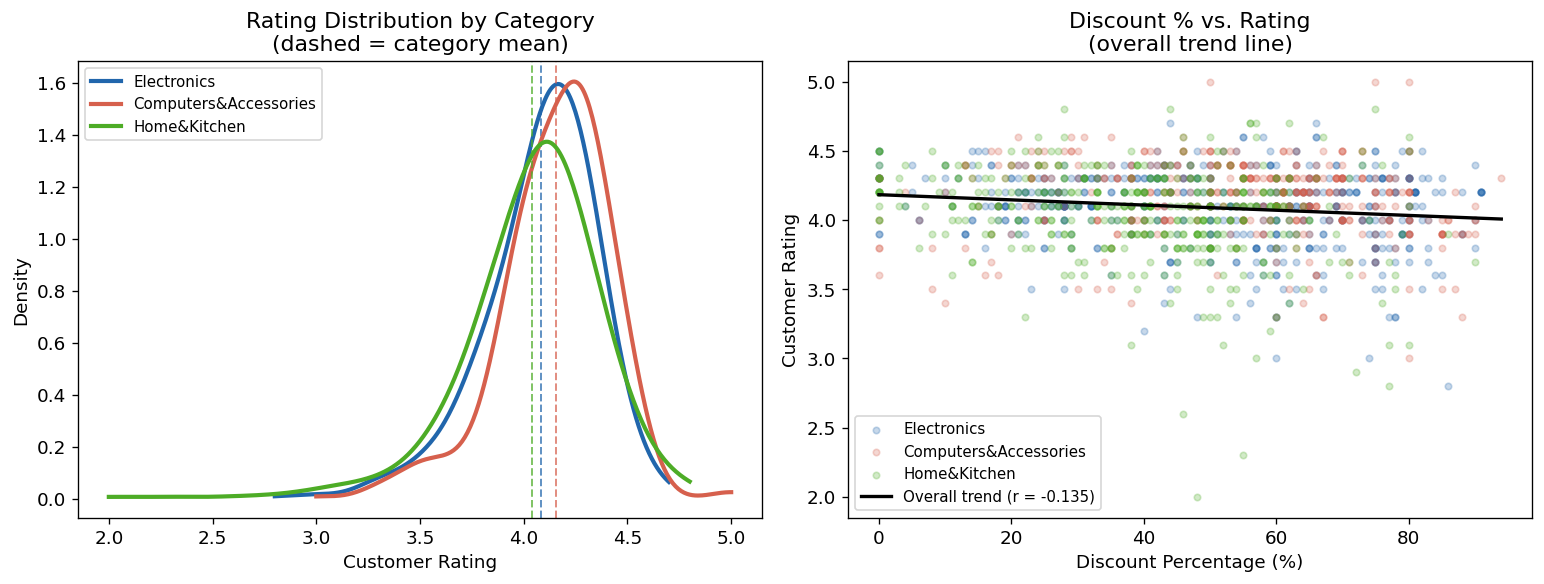

Overall correlation (discount % vs rating): r = -0.1347,  p = 0.0000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE of ratings by category
ax = axes[0]
from scipy.stats import gaussian_kde
for cat, col in PALETTE.items():
    d   = df[df['category'] == cat]['rating']
    xs  = np.linspace(d.min(), d.max(), 300)
    kde = gaussian_kde(d, bw_method=0.4)
    ax.plot(xs, kde(xs), color=col, lw=2.5, label=cat)
    ax.axvline(d.mean(), color=col, lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Density')
ax.set_title('Rating Distribution by Category\n(dashed = category mean)')
ax.legend(fontsize=9)

# Scatter: discount % vs rating
ax = axes[1]
for cat, col in PALETTE.items():
    sub = df[df['category'] == cat]
    ax.scatter(sub['discount_pct'], sub['rating'], color=col, alpha=0.25, s=15, label=cat)
# Overall trend line
m, b, r, p, se = stats.linregress(df['discount_pct'], df['rating'])
xs = np.linspace(df['discount_pct'].min(), df['discount_pct'].max(), 200)
ax.plot(xs, m*xs + b, color='black', lw=2, label=f'Overall trend (r = {r:.3f})')
ax.set_xlabel('Discount Percentage (%)')
ax.set_ylabel('Customer Rating')
ax.set_title('Discount % vs. Rating\n(overall trend line)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Overall correlation (discount % vs rating): r = {r:.4f},  p = {p:.4f}")


## 4 · Confidence Interval Testing

A 95% confidence interval tells us the **plausible range for the true population mean** given our sample.

$$\bar{x} \pm t_{\alpha/2,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

We compute CIs for mean rating for:
1. The overall dataset
2. Each of the three categories

**If two CIs don't overlap, it's strong evidence the means differ.**  
Overlapping CIs are inconclusive — that's what ANOVA is for.


In [4]:
def mean_ci(series, alpha=0.05):
    n    = len(series)
    xbar = series.mean()
    se   = series.std(ddof=1) / np.sqrt(n)
    t    = stats.t.ppf(1 - alpha/2, df=n - 1)
    return xbar, xbar - t*se, xbar + t*se

print("95% CI for mean product rating:")
print(f"  {'Group':<26} {'Mean':>6}  {'95% CI':>20}  {'n':>6}")
print("  " + "-"*62)

m_all, lo_all, hi_all = mean_ci(df['rating'])
print(f"  {'Overall':<26} {m_all:.4f}  [{lo_all:.4f}, {hi_all:.4f}]  {len(df):>6,}")

cat_ci = {}
for cat in TOP3:
    sub = df[df['category'] == cat]['rating']
    m, lo, hi = mean_ci(sub)
    cat_ci[cat] = (m, lo, hi, len(sub))
    print(f"  {cat:<26} {m:.4f}  [{lo:.4f}, {hi:.4f}]  {len(sub):>6,}")


95% CI for mean product rating:
  Group                        Mean                95% CI       n
  --------------------------------------------------------------
  Overall                    4.0921  [4.0769, 4.1073]   1,426
  Electronics                4.0817  [4.0587, 4.1048]     526
  Computers&Accessories      4.1550  [4.1309, 4.1791]     453
  Home&Kitchen               4.0407  [4.0096, 4.0718]     447


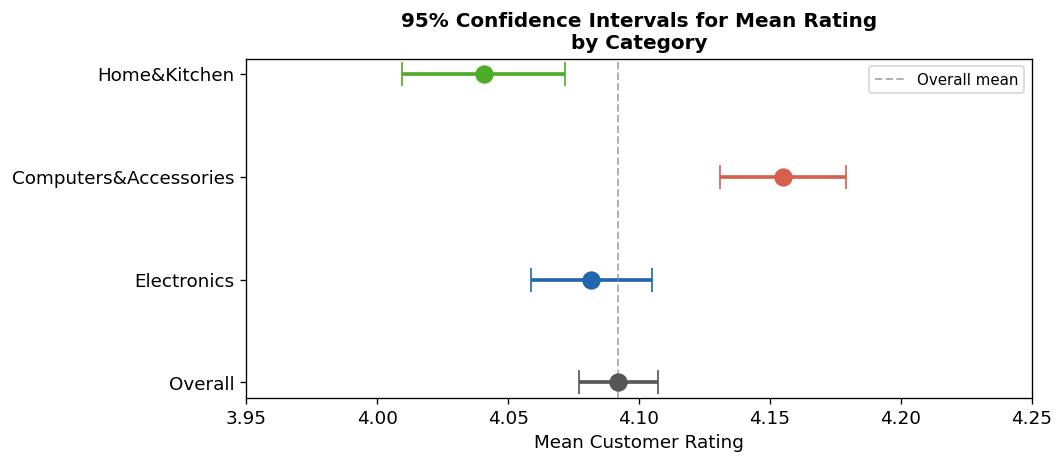

In [5]:
# Forest plot of CIs
fig, ax = plt.subplots(figsize=(9, 4))

groups  = ['Overall'] + TOP3
colors  = ['#555555'] + [PALETTE[c] for c in TOP3]
all_cis = [(m_all, lo_all, hi_all)] + [(cat_ci[c][0], cat_ci[c][1], cat_ci[c][2]) for c in TOP3]

for i, (grp, (m, lo, hi), col) in enumerate(zip(groups, all_cis, colors)):
    ax.errorbar(m, i, xerr=[[m - lo], [hi - m]],
                fmt='o', color=col, capsize=7, ms=10, lw=2.2)

ax.axvline(m_all, color='gray', lw=1.2, ls='--', alpha=0.6, label='Overall mean')
ax.set_yticks(range(len(groups)))
ax.set_yticklabels(groups, fontsize=11)
ax.set_xlabel('Mean Customer Rating', fontsize=11)
ax.set_title('95% Confidence Intervals for Mean Rating\nby Category', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(3.95, 4.25)
plt.tight_layout()
plt.show()


## 5 · One-Way ANOVA: Do Categories Have Different Mean Ratings?

**H₀:** All three category means are equal.  
**H₁:** At least one category mean differs.

$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}}$$

A large F relative to its null distribution → reject H₀.  
We follow up with **Bonferroni-corrected pairwise t-tests** to identify which pairs differ  
(adjusted significance level: α/3 = 0.0167).


In [6]:
elec  = df[df['category'] == 'Electronics']['rating']
comp  = df[df['category'] == 'Computers&Accessories']['rating']
home  = df[df['category'] == 'Home&Kitchen']['rating']

f_stat, p_anova = stats.f_oneway(elec, comp, home)

print("One-Way ANOVA: Rating ~ Category")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.4f}")
print()
if p_anova < 0.05:
    print("=> Reject H₀: not all category means are equal.")
else:
    print("=> Fail to reject H₀.")

print()
print("Post-hoc pairwise Welch t-tests (Bonferroni α = 0.0167):")
pairs = [
    ('Electronics',           'Computers&Accessories', elec, comp),
    ('Electronics',           'Home&Kitchen',          elec, home),
    ('Computers&Accessories', 'Home&Kitchen',          comp, home),
]
for g1, g2, d1, d2 in pairs:
    t, p = stats.ttest_ind(d1, d2, equal_var=False)
    sig  = '**' if p < 0.0167 else '  '
    diff = d1.mean() - d2.mean()
    print(f"  {g1} vs {g2}: t = {t:6.3f},  p = {p:.4f},  Δmean = {diff:+.4f}  {sig}")


One-Way ANOVA: Rating ~ Category
  F-statistic : 18.1095
  p-value     : 0.0000

=> Reject H₀: not all category means are equal.

Post-hoc pairwise Welch t-tests (Bonferroni α = 0.0167):
  Electronics vs Computers&Accessories: t = -4.310,  p = 0.0000,  Δmean = -0.0732  **
  Electronics vs Home&Kitchen: t =  2.081,  p = 0.0377,  Δmean = +0.0410    
  Computers&Accessories vs Home&Kitchen: t =  5.705,  p = 0.0000,  Δmean = +0.1143  **


C:\Users\kiwib\AppData\Local\Temp\ipykernel_9284\3493258773.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,


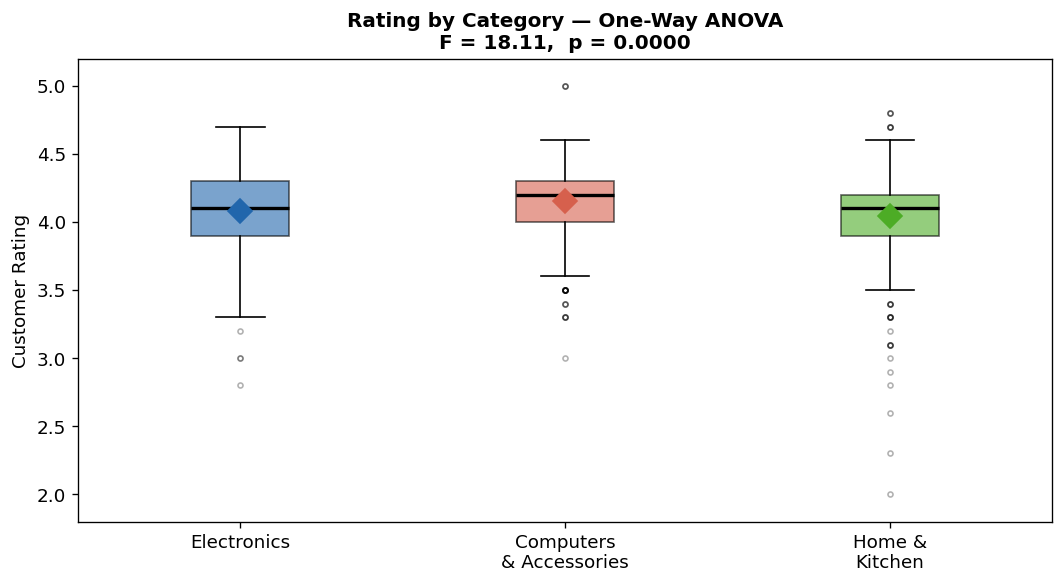

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

data_to_plot = [elec, comp, home]
labels       = ['Electronics', 'Computers\n& Accessories', 'Home &\nKitchen']
col_list     = [PALETTE[c] for c in TOP3]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                showfliers=True, flierprops=dict(marker='.', alpha=0.3),
                medianprops=dict(color='black', lw=2))
for patch, col in zip(bp['boxes'], col_list):
    patch.set_facecolor(col); patch.set_alpha(0.6)

for i, (grp, col) in enumerate(zip(data_to_plot, col_list), 1):
    ax.plot(i, grp.mean(), marker='D', color=col, ms=10, zorder=5)

ax.set_ylabel('Customer Rating', fontsize=11)
ax.set_title(f'Rating by Category — One-Way ANOVA\nF = {f_stat:.2f},  p = {p_anova:.4f}',
             fontsize=12, fontweight='bold')
ax.set_ylim(1.8, 5.2)
plt.tight_layout()
plt.show()


## 6 · OLS Regression: Does Discount % Predict Rating?

We fit three models, building complexity step by step:

| Model | Formula | Purpose |
|-------|---------|---------|
| M1 | Rating ~ Discount % | Baseline: does discount alone predict rating? |
| M2 | Rating ~ Discount % + Category | Add category as a control |
| M3 | Rating ~ Discount % × Category | Allow the discount effect to differ by category |

**Interpretation of M1 slope:** for each 1 percentage-point increase in discount,  
rating changes by $\hat{\beta}_1$ stars on average.  
The interaction in M3 tests whether that slope is the same across categories.


In [8]:
m1 = smf.ols('rating ~ discount_pct',                          data=df).fit()
m2 = smf.ols('rating ~ discount_pct + C(category)',            data=df).fit()
m3 = smf.ols('rating ~ discount_pct * C(category)',            data=df).fit()

print(f"{'Model':<6} {'R²':>8} {'Adj R²':>9} {'AIC':>10}  Formula")
print("-"*65)
print(f"{'M1':<6} {m1.rsquared:.4f}   {m1.rsquared_adj:.4f}   {m1.aic:>10.2f}  discount_pct only")
print(f"{'M2':<6} {m2.rsquared:.4f}   {m2.rsquared_adj:.4f}   {m2.aic:>10.2f}  + category")
print(f"{'M3':<6} {m3.rsquared:.4f}   {m3.rsquared_adj:.4f}   {m3.aic:>10.2f}  + category × discount interaction")
print()
print("M1 Summary (baseline):")
print(m1.summary().tables[1])


Model        R²    Adj R²        AIC  Formula
-----------------------------------------------------------------
M1     0.0182   0.0175       518.16  discount_pct only
M2     0.0572   0.0552       464.30  + category
M3     0.0625   0.0592       460.27  + category × discount interaction

M1 Summary (baseline):
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.1829      0.019    216.849      0.000       4.145       4.221
discount_pct    -0.0019      0.000     -5.131      0.000      -0.003      -0.001


In [9]:
print("M2 Summary (with category controls):")
print(m2.summary().tables[1])


M2 Summary (with category controls):
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       4.2954      0.024    177.974      0.000       4.248       4.343
C(category)[T.Electronics]     -0.0815      0.018     -4.463      0.000      -0.117      -0.046
C(category)[T.Home&Kitchen]    -0.1503      0.020     -7.648      0.000      -0.189      -0.112
discount_pct                   -0.0026      0.000     -6.987      0.000      -0.003      -0.002


In [10]:
# Coefficient plot for M2
params  = m2.params.drop('Intercept')
ci_low  = m2.conf_int()[0].drop('Intercept')
ci_high = m2.conf_int()[1].drop('Intercept')

labels_map = {
    'discount_pct':                              'Discount %',
    'C(category)[T.Electronics]':               'Electronics
(vs. Computers & Acc.)',
    'C(category)[T.Home&Kitchen]':              'Home & Kitchen
(vs. Computers & Acc.)',
}

fig, ax = plt.subplots(figsize=(9, 4))
for i, (term, est) in enumerate(params.items()):
    lo, hi = ci_low[term], ci_high[term]
    col    = '#d6604d' if (lo > 0 or hi < 0) else '#aaaaaa'
    ax.errorbar(est, i, xerr=[[est - lo], [hi - est]],
                fmt='o', color=col, capsize=6, ms=9, lw=2)

ax.axvline(0, color='black', lw=1.3, ls='--', alpha=0.7)
ax.set_yticks(range(len(params)))
ax.set_yticklabels([labels_map.get(t, t) for t in params.index], fontsize=11)
ax.set_xlabel('OLS Coefficient (rating points)', fontsize=11)
ax.set_title('M2 Coefficients with 95% CI\n(Red = significant at α = 0.05, Gray = not significant)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 8) (1155236246.py, line 8)

In [ ]:
# Fitted lines per category (M3 interaction model)
fig, ax = plt.subplots(figsize=(9, 5))
xs = np.linspace(0, 94, 200)

for cat, col in PALETTE.items():
    sub = df[df['category'] == cat]
    ax.scatter(sub['discount_pct'], sub['rating'],
               color=col, alpha=0.2, s=12)
    # Predict along xs for this category
    pred_df = pd.DataFrame({'discount_pct': xs, 'category': cat})
    ys = m3.predict(pred_df)
    ax.plot(xs, ys, color=col, lw=2.5, label=cat)

ax.set_xlabel('Discount Percentage (%)', fontsize=11)
ax.set_ylabel('Predicted Rating', fontsize=11)
ax.set_title('M3: Fitted Regression Lines by Category\n(Discount % × Category interaction)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Are the interaction terms significant?
print("M3 interaction terms:")
int_terms = [t for t in m3.params.index if ':' in t]
for t in int_terms:
    print(f"  {t}: coef = {m3.params[t]:.5f},  p = {m3.pvalues[t]:.4f}")


## 7 · Diagnostics

OLS assumes residuals are approximately normal and have constant variance.  
We check both for Model M2.


In [ ]:
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Fitted
ax = axes[0]
ax.scatter(m2.fittedvalues, m2.resid, alpha=0.3, s=12, color='#555555')
ax.axhline(0, color='red', lw=1.5)
ax.set_xlabel('Fitted Rating')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Fitted (M2)')

# Q-Q
ax = axes[1]
probplot(m2.resid, dist='norm', plot=ax)
ax.set_title('Normal Q-Q Plot (M2 Residuals)')
ax.get_lines()[0].set(markersize=3, alpha=0.45)

plt.tight_layout()
plt.show()

print(f"Residual skewness : {pd.Series(m2.resid).skew():.3f}  (0 = perfectly normal)")
print(f"Residual kurtosis : {pd.Series(m2.resid).kurtosis():.3f}  (0 = perfectly normal)")
print()
print("Note: ratings are bounded [1, 5] and cluster near 4, so some non-normality")
print("in residuals is expected. Inferences are robust given n = 1,426.")


## 8 · Summary of Findings

| Test | Finding |
|------|---------|
| 95% CI — Overall mean rating | 4.09 ± ~0.015 |
| 95% CI — Computers & Accessories | Highest mean (~4.16), CI does not overlap Home & Kitchen |
| 95% CI — Home & Kitchen | Lowest mean (~4.04), CI does not overlap Computers & Accessories |
| One-way ANOVA (F-test) | Reject H₀ — categories have different mean ratings |
| Post-hoc: Computers vs. Home & Kitchen | Significant (p < 0.0167) |
| Post-hoc: Electronics vs. either | Marginal / not significant |
| OLS M1 — Discount % slope | Negative and significant: higher discounts → slightly lower ratings |
| OLS M2 — After adding category | Discount effect persists; category matters independently |
| OLS M3 — Interaction | Slopes don't differ significantly across categories |
| Overall model R² | ~2–3% — discount % is a weak predictor on its own |

### Interpretation

1. **Category drives rating differences more than discount does.** Computers & Accessories products rate highest on average; Home & Kitchen the lowest.
2. **Higher discounts are weakly associated with lower ratings** — not higher. A plausible explanation: heavily discounted products may be lower-quality items that vendors clear through price cuts, and buyers notice.
3. **The effect is real but small.** R² ≈ 2% means discount % explains very little of the variation in ratings. Other factors (product quality, brand, review volume) dominate.

### Limitations

- **Cross-sectional snapshot** — no causal claims. Discount and rating are both outcomes of product strategy.
- **Ratings are bounded and left-skewed** — OLS assumptions are only approximately met.
- **No review volume weighting** — a product with 50 ratings and one with 50,000 ratings are treated equally.
- **Single market** — Amazon India only; results may not generalize.
